In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
training_file = "../data/training/diagnostic_data.csv"
testing_file = "../data/testing/diagnositc_testData.csv"

In [12]:
training_df = pd.read_csv(training_file)
testing_df = pd.read_csv(testing_file)

In [13]:
training_df.head()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
0,4.191492,2.612467,0.221937,38.904112,24.325993,32.196748,3.385642,-2.018015,-0.001478,-1.990294,0.210638,3346.937,2988.798734,2494.925688,1993.781164,1660.722284,0
1,4.189773,2.587209,0.220868,38.934590,24.685948,32.351774,3.323879,-2.016821,0.000021,-1.990079,0.211502,3328.828,2970.932149,2476.991823,1981.776433,1651.256208,0
2,4.188187,2.651917,0.215820,38.743649,24.734266,32.277595,3.283721,-2.016574,-0.001754,-1.989882,0.211939,3309.422,2955.190865,2462.807846,1970.217046,1642.873262,0
3,4.188461,2.592948,0.219867,38.672511,24.652244,32.151764,3.276088,-2.015936,0.000234,-1.989586,0.211961,3309.719,2953.807410,2462.541808,1969.481263,1641.440990,0
4,4.188299,2.547420,0.222766,38.558828,24.518700,32.014608,3.280730,-2.017426,0.001701,-1.990128,0.211820,3307.688,2955.855436,2462.511873,1968.414178,1640.533634,0


In [14]:
testing_df.head()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
0,4.188109,2.472161,0.223212,38.071170,23.819520,31.641007,3.307729,-2.012995,0.001459,-1.997846,0.149811,3357.531,2991.426631,2493.944123,1993.609575,1661.113647,0
1,4.186516,2.411438,0.224328,38.089602,24.314787,31.777782,3.182350,-2.012644,0.002301,-1.997081,0.150847,3337.469,2974.809976,2478.196886,1983.490158,1652.094076,0
2,4.188811,2.394396,0.224424,37.481917,23.741692,31.183386,3.176339,-2.011824,0.001565,-1.996671,0.151406,3331.719,2967.209049,2474.573668,1980.602620,1649.134581,0
3,4.188875,2.399948,0.223174,36.984057,23.227857,30.670948,3.191724,-2.013527,-0.001904,-1.996717,0.151974,3315.672,2956.927023,2460.873406,1968.118685,1640.144123,0
4,4.189872,2.385146,0.224679,38.147535,24.414642,31.786541,3.195343,-2.014479,-0.002049,-1.997700,0.152577,3317.703,2956.505647,2463.451319,1970.793020,1642.486382,0


In [15]:
print(f"training shape: {training_df.shape}")
print(f"testing shape: {testing_df.shape}")

training shape: (499, 17)
testing shape: (129, 17)


<Axes: xlabel='degradation', ylabel='count'>

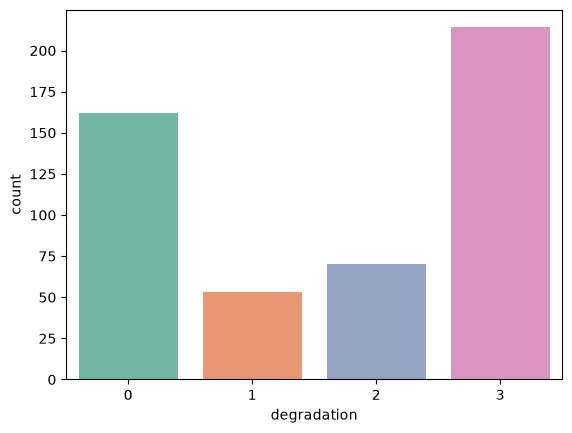

In [29]:
sns.countplot(training_df, x='degradation', hue='degradation', palette="Set2", legend=False)

<Axes: xlabel='degradation', ylabel='count'>

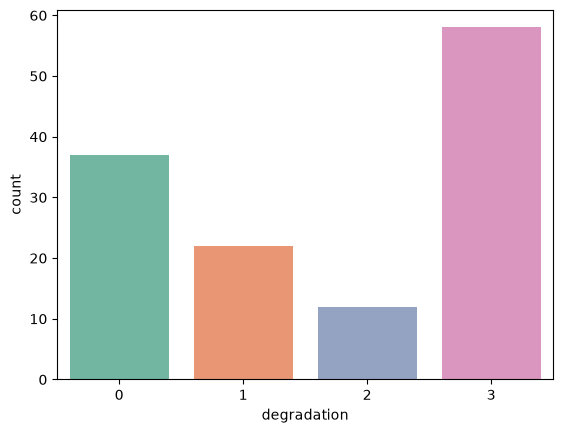

In [37]:
sns.countplot(testing_df, x='degradation', hue='degradation', palette="Set2", legend=False)

<Axes: >

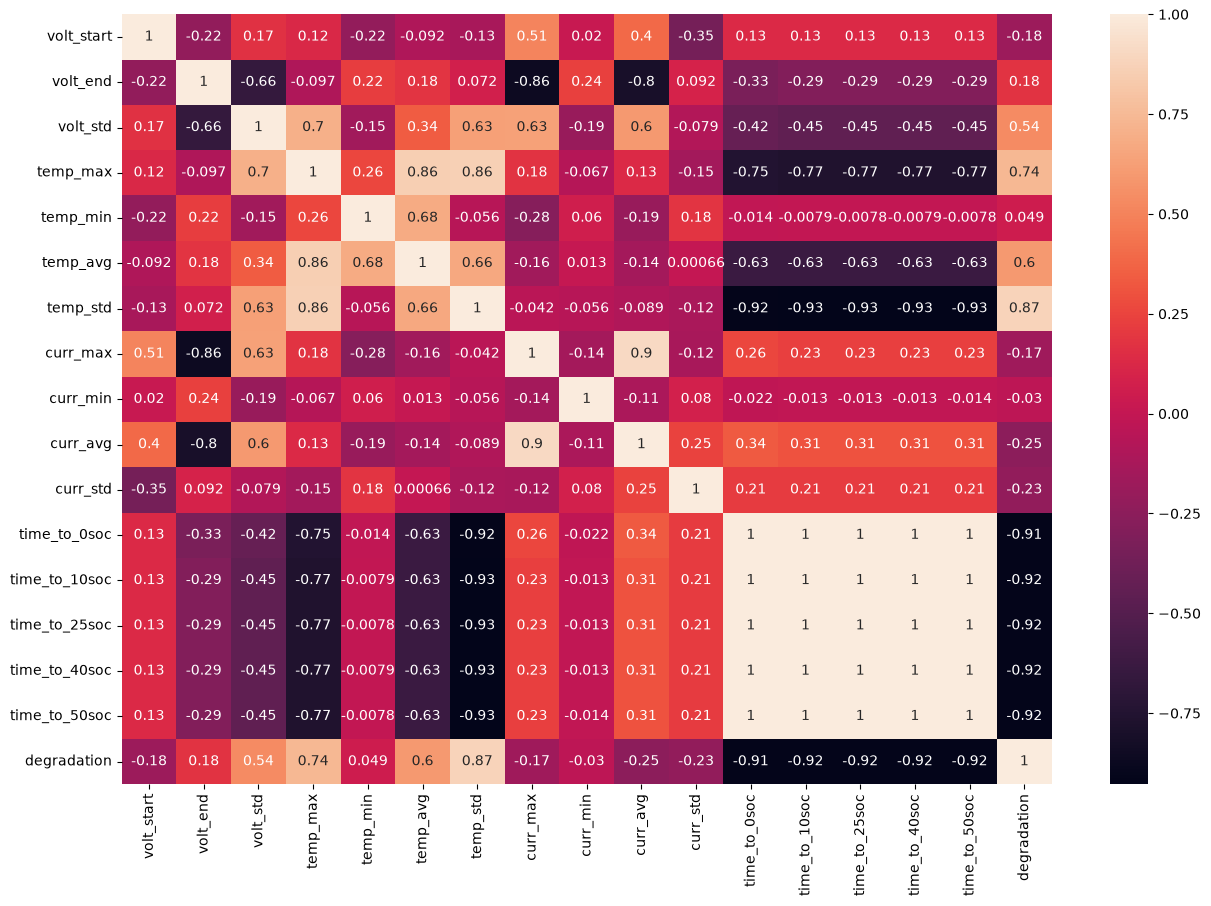

In [36]:
plt.figure(figsize=(15, 10))
sns.heatmap(training_df.corr(), annot=True)

['volt_start', 'volt_end', 'volt_std', 'temp_max', 'temp_min', 'temp_avg', 'temp_std', 'curr_max', 'curr_min', 'curr_avg', 'curr_std', 'time_to_0soc', 'time_to_10soc', 'time_to_25soc', 'time_to_40soc', 'time_to_50soc']


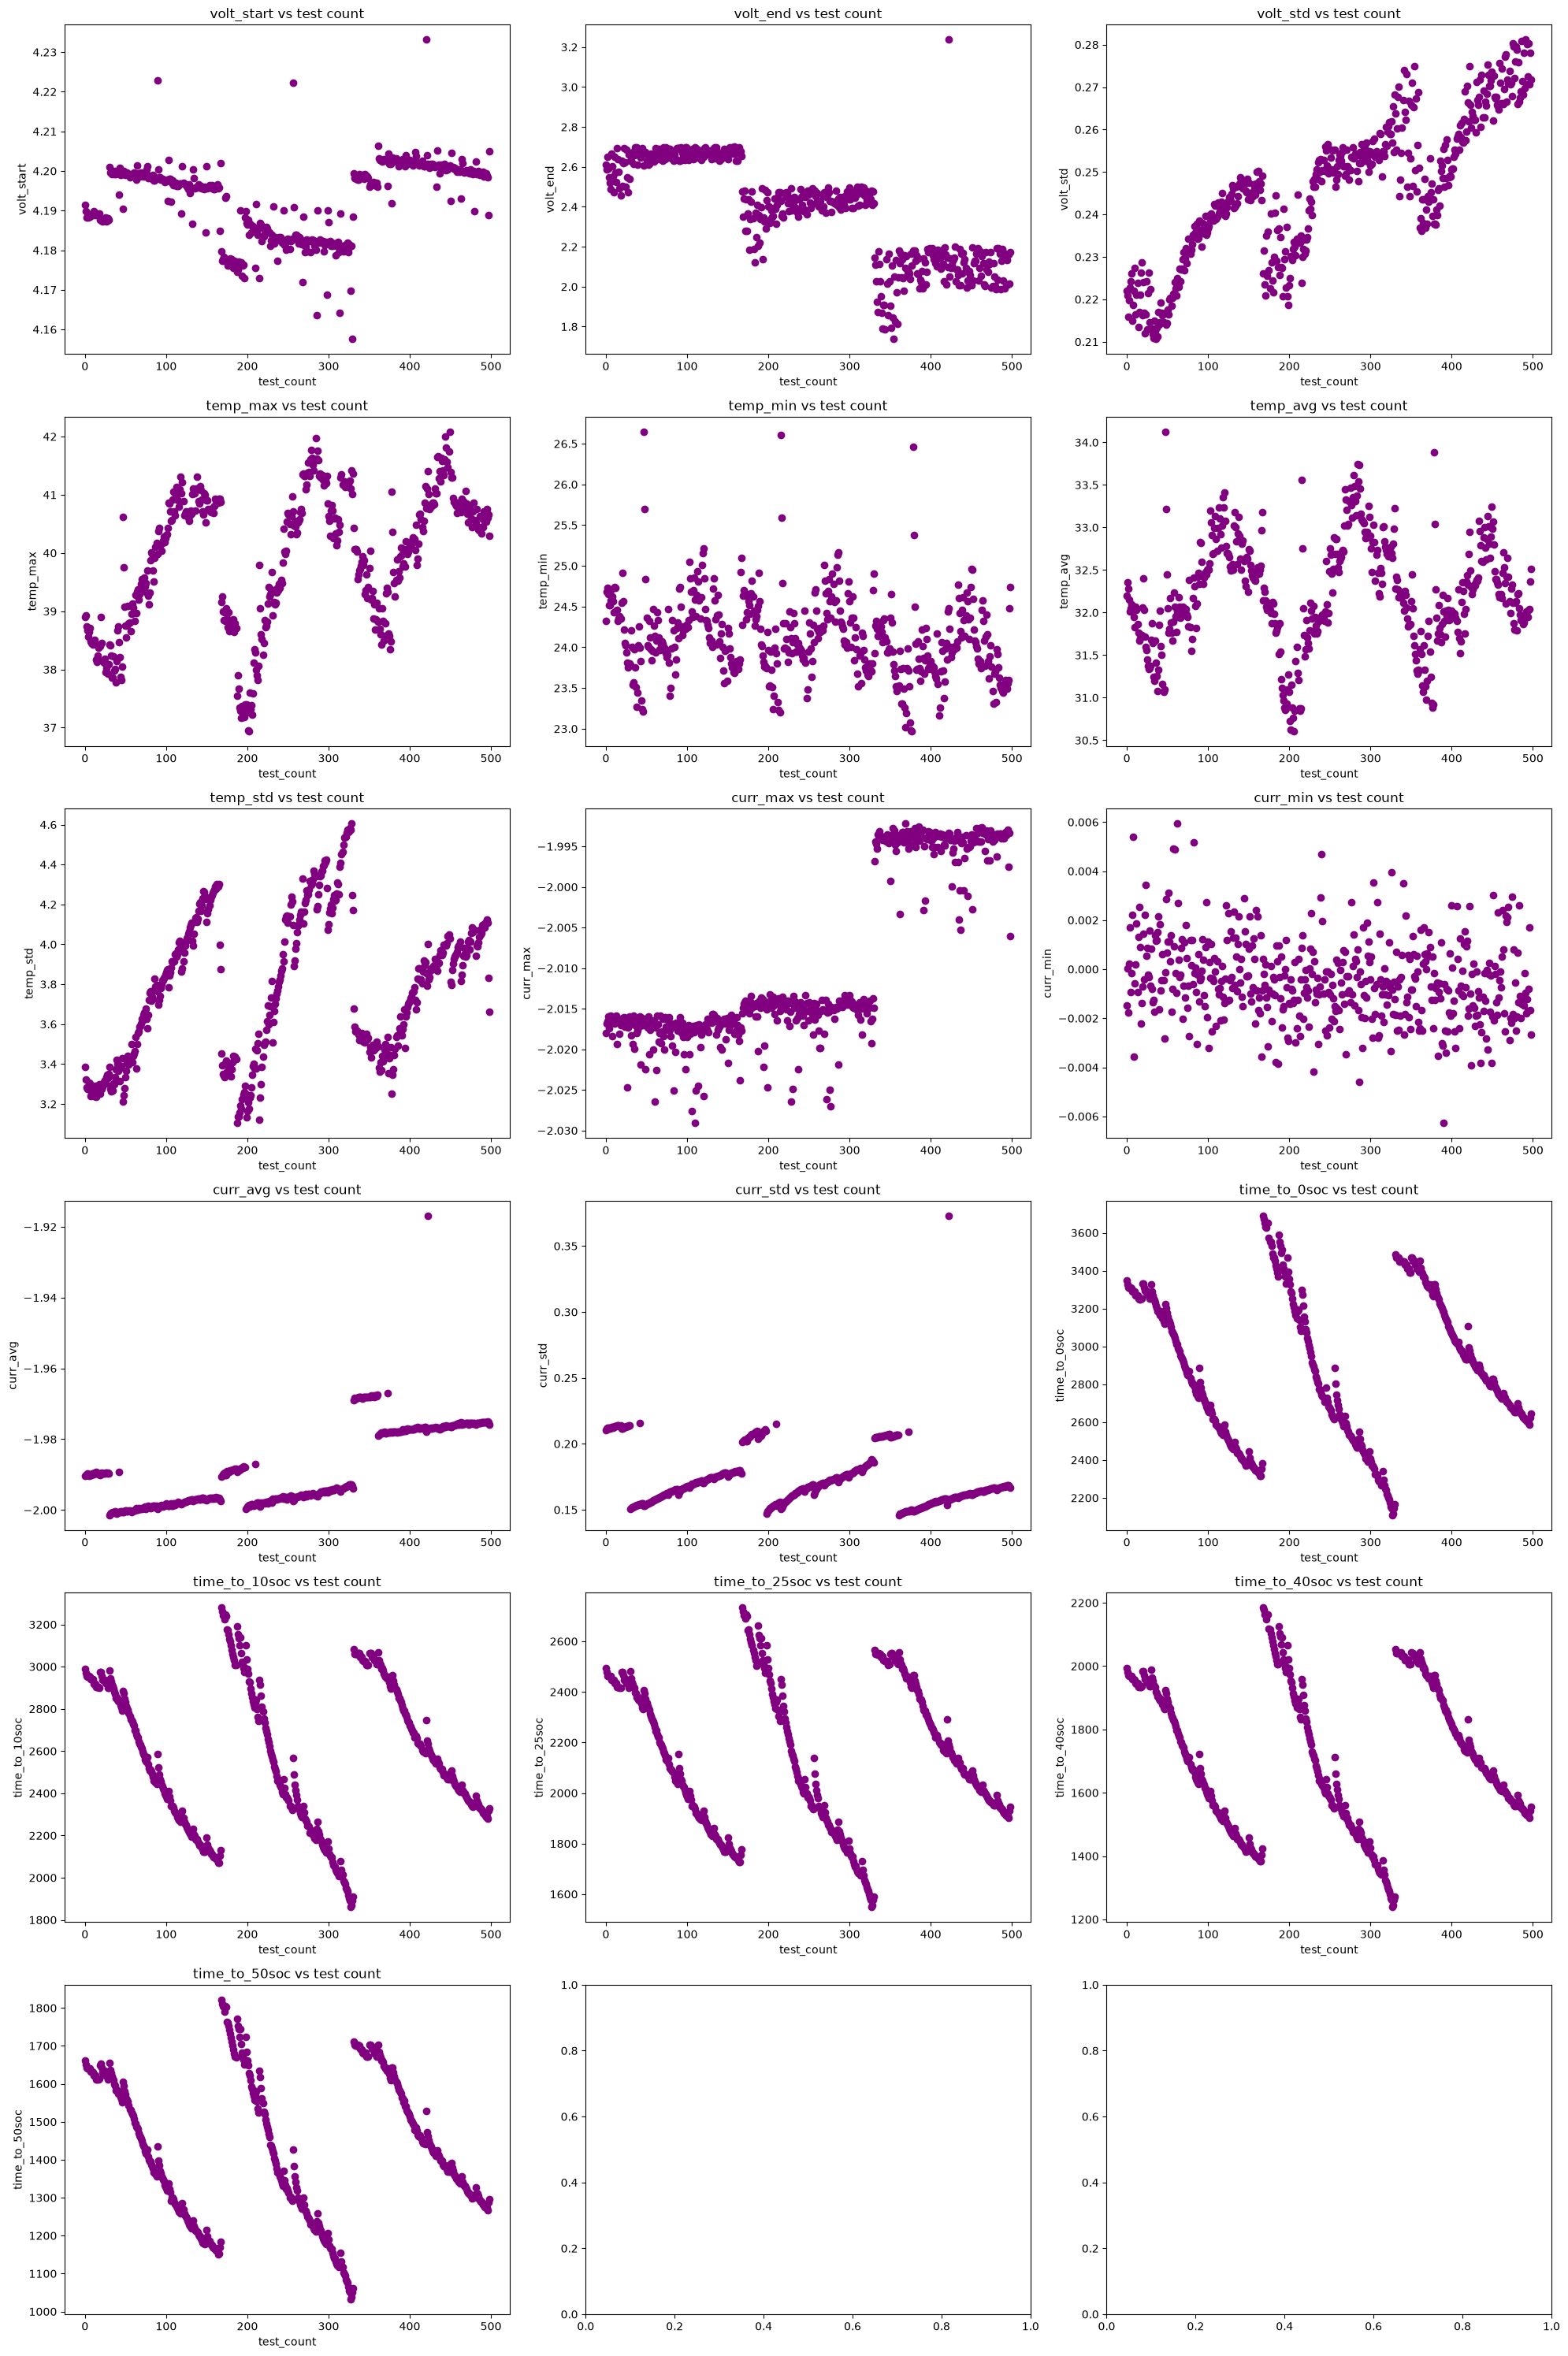

In [24]:
import math

total_features = training_df.shape[1]
num_col = 3
num_rows = math.ceil(total_features / num_col)

fig, ax = plt.subplots(nrows=num_rows, ncols=num_col, figsize=(20,30))
ax = ax.flatten()

features = [col for col in training_df.columns if col != "degradation"]

for i, feature in enumerate(features):
    ax[i].scatter(range(len(training_df[feature])), training_df[feature], color="purple")
    ax[i].set_title(f'{feature} vs test count')
    ax[i].set_xlabel("test_count")
    ax[i].set_ylabel(feature)

fig.tight_layout()

print(features)